In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import platform
warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
print("=" * 60)
print("로드 완료")
print("=" * 60)

로드 완료


In [ ]:
"""
제거 대상 컬럼
"""

drop_columns = [
    # ── 그룹 1: 사후 상환 실적 ──
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'last_pymnt_amnt', 'last_pymnt_d', 'next_pymnt_d',

    # ── 그룹 2: 잔액 사후 정보 ──
    'out_prncp', 'out_prncp_inv',

    # ── 그룹 3: 상각/추심 사후 ──
    'recoveries', 'collection_recovery_fee',

    # ── 그룹 4: 사후 신용 스냅샷 ──
    'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low',

    # ── 그룹 5: Hardship / Settlement ──
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date',
    'hardship_length', 'hardship_dpd', 'hardship_loan_status',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
    'orig_projected_additional_accrued_interest',
    'debt_settlement_flag', 'debt_settlement_flag_date', 'settlement_status',
    'settlement_date', 'settlement_amount', 'settlement_percentage', 'settlement_term',

    # ── 그룹 6: 특별 상환 계획 ──
    'pymnt_plan', 'payment_plan_start_date',

    # ── 그룹 7: 승인/집행 결과 ──
    'funded_amnt', 'funded_amnt_inv', 'disbursement_method',

    # ── 그룹 8: 식별자 및 상수 ──
    'id', 'member_id', 'url', 'title', 'zip_code', 'policy_code',

    # ── 그룹 9: 원본 타겟 변수 ──
    'loan_status',

    # ── 그룹 10: 효과 크기 낮은 변수 ── 후보 
    #'initial_list_status', 'total_acc', 'open_acc',
    #'application_type', 'addr_state', 'earliest_cr_line', 'pub_rec',

    # ── 그룹 11: 공동 신청(Joint) 관련 ──
    'annual_inc_joint', 'dti_joint', 'verification_status_joint',
    'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high',
    'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc',
    'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il',
    'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths',
    'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog',

    # 2016년 이후 신규 추가된 세부 신용 리포트 항목 (13개) 
    "open_acc_6m", "open_act_il", "open_il_12m", "open_il_24m","total_bal_il"
    ,"il_util","open_rv_12m","open_rv_24m","max_bal_bc","all_util","inq_fi" 
    ,"total_cu_tl", "inq_last_12m",

    # 3차 검토 사용 불가 판정 
    "desc", "emp_title", "num_tl_120dpd_2m", 

]

# 중복 검증
assert len(drop_columns) == len(set(drop_columns)), \
    f"중복 존재: {[c for c in drop_columns if drop_columns.count(c) > 1]}"

print(f"총 제거 대상: {len(drop_columns)}개")

# 실제 적용
df = df.drop(columns=[c for c in drop_columns if c in df.columns])

총 제거 대상: 80개


In [ ]:
# 전체 컬럼의 null 여부 
null_info = pd.DataFrame({
    '결측수': df.isnull().sum(),
    '결측률': df.isnull().mean().apply(lambda x: f"{x:.2%}")
})
print(null_info[null_info['결측수'] > 0])

                                    결측수     결측률
dti                                 414   0.03%
mths_since_last_delinq           634712  49.67%
mths_since_last_record          1052865  82.40%
mths_since_last_major_derog      924045  72.32%
mths_since_rcnt_il               754388  59.04%
mo_sin_old_il_acct                38045   2.98%
mths_since_recent_bc              12685   0.99%
mths_since_recent_bc_dlq         958775  75.03%
mths_since_recent_inq            124121   9.71%
mths_since_recent_revol_delinq   832930  65.18%
pct_tl_nvr_dlq                      154   0.01%


In [ ]:
"""
통합전처리
"""
# mo_sin_old_rev_tl_op이 null인 행 제거 
df = df.dropna(subset=["mo_sin_old_rev_tl_op"]) # null 1
df = df.dropna(subset=["num_rev_accts"]) # null 1


#날짜형 변수 변환 
#df['issue_d'] = pd.to_datetime(df['issue_d'], errors="coerce")
df['issue_year'] = df['issue_d'].dt.year #연도별 변수 
#df['issue_month'] = df['issue_d'].dt.month # 월별 변수 

# 범주형 변수 처리
df["emp_length"] = df["emp_length"].fillna("unknown") # 근속 연수 결측치는  unknown 처리
df["home_ownership"] = df["home_ownership"].replace(["ANY","NONE"],"OTHER" ) # 주거 형태  OTHER 로 통합 

# 수치형 변수 처리
df["inq_last_6mths"] = df['inq_last_6mths'].fillna(0) #  최근 6개월간 신용 조회(hard inquiry) 횟수 결측치 1
df["revol_util"]= df["revol_util"].fillna(0) #리볼빙 이용률 (%) 
df["bc_open_to_buy"]= df["bc_open_to_buy"].fillna(0) #뱅크카드 잔여 한도 ($) 
df["bc_util"]= df["bc_util"].fillna(0) #뱅크카드 이용률 (%)
df["percent_bc_gt_75"]= df["percent_bc_gt_75"].fillna(0) #뱅크카드 75%인 뱅크카드 비율 (%) 
df["dti"] = df["dti"].replace(999, np.nan) # dti 변경전 >> 결측치 Null 로 변경
df.loc[df["dti"] < 0, "dti"] = np.nan

# 전체 계좌 평균 잔액 ($) 이 null 인행 제거 
df = df.dropna(subset=["avg_cur_bal"])

# 파생 변수 생성 
# 신용 조회, 결측이라면 연체가 없다는 의미 
cols = [
'mths_since_last_delinq',
'mths_since_last_record',
'mths_since_last_major_derog',
'mths_since_recent_revol_delinq',
'mths_since_recent_bc_dlq',
'mths_since_rcnt_il', 
'mths_since_recent_inq', 
'mths_since_recent_bc'
]

for col in cols:
    df[col+"_missing"] = df[col].isna().astype(int) # 결측값일때 1 아닐때 0, 1이라는 것은 연체가 없다는 것 
    # max_val = df[col].max()
    # df[col] = df[col].fillna(max_val + 1) 

# 범죄 유무 컬럼 범주형 
# 범죄를 한번이라도 했다면 fraud_has 아니면 fraud_hasn't
df["is_pub_rec"] = np.where(df["pub_rec"] ==0,"fraud_hasn't", "fraud_has" )

# # 대출 당시 신용 조회 평균 
df['fico_mid'] = (df['fico_range_low'] + df['fico_range_high'])/2
df = df.drop(columns=['fico_range_low', 'fico_range_high']) # 제거 
 


In [ ]:
# # 전처리한 데이터 내보내기 
# df.to_csv("data/ending_club_preprocessed.csv", index=False)

In [ ]:
### test 데이터 분할 하고 처리해야 하는 데이터 
## dti 

# 
# - dti train_test 분리후
# - df["dti"] = df.groupby("grade")["dti"].transform(
#      lambda x: x.fillna(x.median())
# >> 신용등급별 대표값 채우기 


## mo_sin_old_il_acct설명 가장 오래된 할부 계좌 이후 경과 월수
## 최대값 +1 

# pct_tl_nvr_dlq 연체 이력이 한 번도 없는 계좌 비율 (%)
## 중앙값으로 채우기 

In [ ]:
# 다중 공선성이 의심되는 컬럼들

# 6 
Revolving= [
    "revol_bal","revol_util", "total_rev_hi_lim"

]

Bc_card = [
    "bc_open_to_buy", "bc_util", "percent_bc_gt_75", "total_bc_limit","num_actv_bc_tl",
    "num_actv_rev_tl","num_bc_sats"
]

In [6]:
# 의사결정트리 모델 시작

df = pd.read_csv('ending_club_preprocessed.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'ending_club_preprocessed.csv'

In [4]:
df.shape

(1277799, 81)

In [ ]:
missing_info = df.isnull().sum()
missing_info = flag_info[flag_info > 0]
print(flag_info)

dti                                   414
mths_since_last_delinq             634712
mths_since_last_record            1052865
mths_since_last_major_derog        924045
mths_since_rcnt_il                 754388
mo_sin_old_il_acct                  38045
mths_since_recent_bc                12685
mths_since_recent_bc_dlq           958775
mths_since_recent_inq              124121
mths_since_recent_revol_delinq     832930
pct_tl_nvr_dlq                        154
dtype: int64


<class 'pandas.DataFrame'>
RangeIndex: 1277799 entries, 0 to 1277798
Data columns (total 81 columns):
 #   Column                                  Non-Null Count    Dtype  
---  ------                                  --------------    -----  
 0   loan_amnt                               1277799 non-null  float64
 1   term                                    1277799 non-null  str    
 2   int_rate                                1277799 non-null  float64
 3   installment                             1277799 non-null  float64
 4   grade                                   1277799 non-null  str    
 5   sub_grade                               1277799 non-null  str    
 6   emp_length                              1277799 non-null  str    
 7   home_ownership                          1277799 non-null  str    
 8   annual_inc                              1277799 non-null  float64
 9   verification_status                     1277799 non-null  str    
 10  issue_d                                 1

In [8]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols

['term',
 'grade',
 'sub_grade',
 'emp_length',
 'home_ownership',
 'verification_status',
 'issue_d',
 'purpose',
 'addr_state',
 'earliest_cr_line',
 'initial_list_status',
 'application_type',
 'is_pub_rec']

In [7]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
       'issue_d', 'purpose', 'addr_state', 'dti', 'delinq_2yrs',
       'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal',
       'mths_since_rcnt_il', 'total_rev_hi_lim', 'acc_open_past_24mths',
       'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths',
       'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op',
       'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc',
       'mths_since_recent_bc', 'mths_since_recent_bc_dlq',
       'mths_since_recent_inq', 'mths_since_recent_revol_delinq',
       'num_accts_ever_120_pd', 'n

In [21]:
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_curve,
    roc_auc_score
)
import matplotlib.pyplot as plt

# 1) 데이터 로드


# 2) 간단한 EDA
print("\n결측치:\n", df.isnull().sum().sort_values(ascending=False).head(10))
print("\n타겟 비율:\n", df["target"].value_counts(normalize=True))

# 3) Name 컬럼 추가
use_cols = ['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'issue_d', 'purpose', 'addr_state', 'dti', 'delinq_2yrs',
    'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq',
    'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
    'revol_util', 'total_acc', 'initial_list_status',
    'collections_12_mths_ex_med', 'mths_since_last_major_derog',
    'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal',
    'mths_since_rcnt_il', 'total_rev_hi_lim', 'acc_open_past_24mths',
    'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths',
    'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op',
    'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc',
    'mths_since_recent_bc', 'mths_since_recent_bc_dlq',
    'mths_since_recent_inq', 'mths_since_recent_revol_delinq',
    'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
    'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
    'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_30dpd',
    'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq',
    'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens',
    'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
    'total_il_high_credit_limit', 'target', 'issue_year',
    'mths_since_last_delinq_flag', 'mths_since_last_record_flag',
    'mths_since_last_major_derog_flag',
    'mths_since_recent_revol_delinq_flag',
    'mths_since_recent_bc_dlq_flag', 'mths_since_rcnt_il_flag',
    'mths_since_recent_inq_flag', 'mths_since_recent_bc_flag',
    'is_pub_rec', 'fico_mid']
df = df[use_cols].copy()

y = df["target"]
X = df.drop(columns=["target"])

# 4) train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# (A) 컬럼 구분
num_median_cols = ['dti', 'pct_tl_nvr_dlq']
num_999_cols = ['mths_since_last_delinq',     
'mths_since_last_record',            
'mths_since_last_major_derog',        
'mths_since_rcnt_il',           
'mo_sin_old_il_acct',          
'mths_since_recent_bc',          
'mths_since_recent_bc_dlq',     
'mths_since_recent_inq',    
'mths_since_recent_revol_delinq']

cat_cols = ['term', 'grade',
'sub_grade',
'emp_length',
'home_ownership',
'verification_status',
'issue_d',
'purpose',
'addr_state',
'earliest_cr_line',
'initial_list_status',
'application_type',
'is_pub_rec']

all_num_cols = X_train.select_dtypes(include="number").columns.tolist()
already_used_num = set(num_median_cols) | set(num_999_cols)
num_other_cols = [c for c in all_num_cols if c not in already_used_num]

num_median_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

num_999_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=999)),
])

num_other_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num_med", num_median_pipeline, num_median_cols),
        ("num_999", num_999_pipeline, num_999_cols),
        ("num_oth", num_other_pipeline, num_other_cols),
        ("cat", cat_pipeline, cat_cols),
    ],
    remainder="drop"  # 혹시 빠진 컬럼이 있으면 자동으로 버려서 실수 발견 쉬움
)
pipe = Pipeline([
    ("preprocess", preprocessor),
    ("clf", DecisionTreeClassifier(random_state=42))
])


# 8) GridSearchCV (트리 하이퍼파라미터 튜닝 예시)
param_grid = {
    "clf__max_depth": [None, 3, 5, 7, 10],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 5]
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    error_score="raise"
)

grid.fit(X_train, y_train)

print("\nBest Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)




결측치:
 mths_since_last_record            1052865
mths_since_recent_bc_dlq           958775
mths_since_last_major_derog        924045
mths_since_recent_revol_delinq     832930
mths_since_rcnt_il                 754388
mths_since_last_delinq             634712
mths_since_recent_inq              124121
mo_sin_old_il_acct                  38045
mths_since_recent_bc                12685
dti                                   414
dtype: int64

타겟 비율:
 target
0.0    0.797877
1.0    0.202123
Name: proportion, dtype: float64


KeyError: "['sub_grade', 'addr_state', 'mths_since_last_delinq_flag', 'mths_since_last_record_flag', 'mths_since_last_major_derog_flag', 'mths_since_recent_revol_delinq_flag', 'mths_since_recent_bc_dlq_flag', 'mths_since_rcnt_il_flag', 'mths_since_recent_inq_flag', 'mths_since_recent_bc_flag'] not in index"

In [13]:
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV  # GridSearch → Randomized
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_curve,
    roc_auc_score
)
import matplotlib.pyplot as plt

# 1) 데이터 로드


# 2) 간단한 EDA
print("\n결측치:\n", df.isnull().sum().sort_values(ascending=False).head(10))
print("\n타겟 비율:\n", df["target"].value_counts(normalize=True))

# 3) Name 컬럼 추가
use_cols = ['loan_amnt', 'term', 'int_rate', 'installment', 'grade',
    # ✅ sub_grade 제거 (grade에 포함되는 고카디널리티 컬럼)
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'issue_d', 'purpose',
    # ✅ addr_state 제거 (50개 → OHE 시 컬럼 폭발)
    'dti', 'delinq_2yrs',
    'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq',
    'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
    'revol_util', 'total_acc', 'initial_list_status',
    'collections_12_mths_ex_med', 'mths_since_last_major_derog',
    'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal',
    'mths_since_rcnt_il', 'total_rev_hi_lim', 'acc_open_past_24mths',
    'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths',
    'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op',
    'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc',
    'mths_since_recent_bc', 'mths_since_recent_bc_dlq',
    'mths_since_recent_inq', 'mths_since_recent_revol_delinq',
    'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
    'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
    'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_30dpd',
    'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq',
    'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens',
    'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
    'total_il_high_credit_limit', 'target', 'issue_year',
    'mths_since_last_delinq_missing', 'mths_since_last_record_missing',
    'mths_since_last_major_derog_missing',
    'mths_since_recent_revol_delinq_missing',
    'mths_since_recent_bc_dlq_missing', 'mths_since_rcnt_il_missing',
    'mths_since_recent_inq_missing', 'mths_since_recent_bc_missing',
    'is_pub_rec', 'fico_mid']
df = df[use_cols].copy()

y = df["target"]
X = df.drop(columns=["target"])

# 4) train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ✅ 튜닝용 샘플 30%만 사용 (127만 → 약 38만 행)
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train, train_size=0.3, random_state=42, stratify=y_train
)
print(f"\n튜닝용 샘플 크기: {X_train_sample.shape}")

# (A) 컬럼 구분
num_median_cols = ['dti', 'pct_tl_nvr_dlq']
num_999_cols = ['mths_since_last_delinq',     
'mths_since_last_record',            
'mths_since_last_major_derog',        
'mths_since_rcnt_il',           
'mo_sin_old_il_acct',          
'mths_since_recent_bc',          
'mths_since_recent_bc_dlq',     
'mths_since_recent_inq',    
'mths_since_recent_revol_delinq']

cat_cols = ['term', 'grade',
    # ✅ sub_grade, addr_state 제거
    'emp_length',
    'home_ownership',
    'verification_status',
    'issue_d',
    'purpose',
    'earliest_cr_line',
    'initial_list_status',
    'application_type',
    'is_pub_rec']

all_num_cols = X_train.select_dtypes(include="number").columns.tolist()
already_used_num = set(num_median_cols) | set(num_999_cols)
num_other_cols = [c for c in all_num_cols if c not in already_used_num]

num_median_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

num_999_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=999)),
])

num_other_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num_med", num_median_pipeline, num_median_cols),
        ("num_999", num_999_pipeline, num_999_cols),
        ("num_oth", num_other_pipeline, num_other_cols),
        ("cat", cat_pipeline, cat_cols),
    ],
    remainder="drop"
)
pipe = Pipeline([
    ("preprocess", preprocessor),
    ("clf", DecisionTreeClassifier(random_state=42))
])

# ✅ 파라미터 그리드 축소 (None 제거, 조합 수 감소)
param_grid = {
    "clf__max_depth": [3, 5, 7, 10],       # None 제거 ✅
    "clf__min_samples_split": [2, 10],      # 3개 → 2개 ✅
    "clf__min_samples_leaf": [1, 5]         # 3개 → 2개 ✅
}

# ✅ GridSearchCV → RandomizedSearchCV (225번 → 20번)
grid = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_grid,
    n_iter=20,          # 전체 조합 대신 20번만 탐색 ✅
    cv=3,               # 5 → 3으로 축소 ✅
    scoring="roc_auc",  # accuracy → roc_auc (불균형 데이터에 적합) ✅
    n_jobs=1,
    random_state=42,
    error_score="raise"
)

# ✅ 샘플로 튜닝
grid.fit(X_train_sample, y_train_sample)

print("\nBest Params:", grid.best_params_)
print("Best CV Score (sample):", grid.best_score_)

# ✅ 최적 파라미터로 전체 데이터 재학습
best_pipe = grid.best_estimator_
best_pipe.fit(X_train, y_train)
print("\n전체 데이터로 재학습 완료!")

# 9) 평가
y_pred = best_pipe.predict(X_test)
y_prob = best_pipe.predict_proba(X_test)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


결측치:
 mths_since_last_record            1052865
mths_since_recent_bc_dlq           958775
mths_since_last_major_derog        924045
mths_since_recent_revol_delinq     832930
mths_since_rcnt_il                 754388
mths_since_last_delinq             634712
mths_since_recent_inq              124121
mo_sin_old_il_acct                  38045
mths_since_recent_bc                12685
dti                                   414
dtype: int64

타겟 비율:
 target
0.0    0.797877
1.0    0.202123
Name: proportion, dtype: float64

튜닝용 샘플 크기: (306671, 78)

Best Params: {'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_depth': 7}
Best CV Score (sample): 0.704294891422207


KeyboardInterrupt: 

In [7]:
df2 = pd.read_csv('ending_club_preprocessed2.csv')

In [18]:
df2.info()

df2.isna().sum().sort_values(ascending=False).head(15)

<class 'pandas.DataFrame'>
RangeIndex: 1277799 entries, 0 to 1277798
Data columns (total 80 columns):
 #   Column                               Non-Null Count    Dtype  
---  ------                               --------------    -----  
 0   loan_amnt                            1277799 non-null  float64
 1   term                                 1277799 non-null  str    
 2   int_rate                             1277799 non-null  float64
 3   installment                          1277799 non-null  float64
 4   grade                                1277799 non-null  str    
 5   sub_grade                            1277799 non-null  str    
 6   emp_length                           1277799 non-null  str    
 7   home_ownership                       1277799 non-null  str    
 8   annual_inc                           1277799 non-null  float64
 9   verification_status                  1277799 non-null  str    
 10  issue_d                              1277799 non-null  str    
 11  purpose  

mths_since_last_record            1052865
mths_since_recent_bc_dlq           958775
mths_since_last_major_derog        924045
mths_since_recent_revol_delinq     832930
mths_since_rcnt_il                 754388
mths_since_last_delinq             634712
mths_since_recent_inq              124121
mo_sin_old_il_acct                  38045
mths_since_recent_bc                12685
dti                                   414
pct_tl_nvr_dlq                        154
loan_amnt                               0
grade                                   0
sub_grade                               0
int_rate                                0
dtype: int64

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV  # GridSearch → Randomized
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_curve,
    roc_auc_score
)
import matplotlib.pyplot as plt

use_cols = ['loan_amnt', 'term', 'int_rate', 'sub_grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'purpose', 'dti', 'delinq_2yrs',
    'inq_last_6mths', 'mths_since_last_delinq',
    'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
    'revol_util', 'total_acc', 'initial_list_status',
    'collections_12_mths_ex_med', 'mths_since_last_major_derog',
    'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal',
    'mths_since_rcnt_il', 'total_rev_hi_lim', 'acc_open_past_24mths',
    'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths',
    'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op',
    'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc',
    'mths_since_recent_bc', 'mths_since_recent_bc_dlq',
    'mths_since_recent_inq', 'mths_since_recent_revol_delinq',
    'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
    'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
    'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_30dpd',
    'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq',
    'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens',
    'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
    'total_il_high_credit_limit', 'target', 'issue_year',
    'mths_since_last_delinq_flag', 'mths_since_last_record_flag',
    'mths_since_last_major_derog_flag',
    'mths_since_recent_revol_delinq_flag',
    'mths_since_recent_bc_dlq_flag', 'mths_since_rcnt_il_flag',
    'mths_since_recent_inq_flag', 'mths_since_recent_bc_flag',
    'fico_mid']
#  제거 고려 대상
# 'grade',   # sub_grade와 중복
# 'installment', # loan_amnt + int_rate + term으로 계산되는 파생값
# 'issue_d',     # issue_year로 이미 추출했으면 중복
# 'addr_state',  # 50개 → OHE 시 컬럼 폭발, 노이즈 가능성
# 'earliest_cr_line', # 날짜 문자열 → 그대로 쓰면 의미 없음
df2 = df2[use_cols].copy()

y = df2["target"]
X = df2.drop(columns=["target"])

# 4) train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
# dti 
X_train["dti"] = X_train.groupby("grade")["dti"].transform(lambda x: x.fillna(x.median())
)

train_dit_medi = X_train.groupby("grade")["dti"].median()

X_test["dti"] = X_test["dti"].fillna(X_test["grade"].map(train_dit_medi))

# 신용 조회, 
cols = [
'mths_since_last_delinq',
'mths_since_last_record',
'mths_since_last_major_derog',
'mths_since_recent_revol_delinq',
'mths_since_recent_bc_dlq',
'mths_since_rcnt_il',
'mths_since_recent_inq',
'mths_since_recent_bc'
]
for col in cols:
    max_val = X_train[col].max()
    X_train[col] = X_train[col].fillna(max_val + 1)
    X_test[col] = X_test[col].fillna(max_val + 1)



## mo_sin_old_il_acct 설명 가장 오래된 할부 계좌 이후 경과 월수
## 최대값 +1 
max_t_1 = X_train["mo_sin_old_il_acct"].max()
X_train["mo_sin_old_il_acct"] = X_train["mo_sin_old_il_acct"].fillna(max_t_1 + 1)
X_test["mo_sin_old_il_acct"] = X_test["mo_sin_old_il_acct"].fillna(max_t_1 + 1)

# pct_tl_nvr_dlq 연체 이력이 한 번도 없는 계좌 비율 (%)
## 중앙값으로 채우기 
medi_dlq = X_train["pct_tl_nvr_dlq"].median()
X_train["pct_tl_nvr_dlq"] = X_train["pct_tl_nvr_dlq"].fillna(medi_dlq)
X_test["pct_tl_nvr_dlq"] = X_test["pct_tl_nvr_dlq"].fillna(medi_dlq)

In [45]:
print(X.dtypes.value_counts())

float64    57
str        16
int64       1
Name: count, dtype: int64


In [1]:
from xgboost import XGBClassifier

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_curve,
    roc_auc_score
)
import matplotlib.pyplot as plt

# 중요도 결과 보고 수동으로 정리하는 게 가장 정확
num_cols = ['int_rate', 'issue_year', 'avg_cur_bal', 'acc_open_past_24mths',
            'loan_amnt', 'dti', 'fico_mid', 'annual_inc', 'num_actv_rev_tl',
            'mort_acc', 'mths_since_rcnt_il', 'tot_hi_cred_lim',
            'mths_since_recent_bc', 'total_rev_hi_lim', 'mths_since_recent_inq',
            'num_actv_bc_tl', 'mths_since_last_delinq', 'num_il_tl',
            'total_acc', 'mths_since_last_record', 'num_rev_tl_bal_gt_0',
            'revol_util', 'revol_bal', 'bc_open_to_buy']

cat_cols = ['grade', 'term', 'emp_length', 'home_ownership', 'verification_status']

# 파이프 라인 생성 
# 수치형 파이프 라인 
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# 범주형 파이프 라인: 원핫 
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# 전처리 통합 ──
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# 전체 파이프라인: 전처리 + 모델 ──
pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
    scale_pos_weight=4,      # 꼭 추가
    max_depth=6,
    n_estimators=200,        # 100 → 200으로 늘리기
    learning_rate=0.05,      # 0.1 → 0.05로 낮추기
    subsample=0.8,           # 추가
    colsample_bytree=0.8,    # 추가
    random_state=42
))
])

# 8) GridSearchCV (트리 하이퍼파라미터 튜닝 예시)
param_grid = {
    "model__max_depth": [4, 6],
    "model__n_estimators": [100],      # 200 제거
    "model__learning_rate": [0.1]      # 하나만
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=3,               # 속도 위해 5 → 3 권장
    scoring={'roc_auc': 'roc_auc', 'accuracy': 'accuracy'},
    refit='roc_auc',
    n_jobs=1,
    error_score="raise"
)

grid.fit(X_train, y_train)

print("\nBest Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)




Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 100}
Best CV Score: 0.7308357708367049


In [ ]:
# 9) test 평가
best_model = grid.best_estimator_
y_prob = grid.best_estimator_.predict_proba(X_test)[:, 1]

# ✅ threshold 조정 (기본 0.5 → 원하는 값으로 변경)
threshold = 0.4
pred = (y_prob >= threshold).astype(int)

print("\nTest Accuracy:", accuracy_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, pred))


Test Accuracy: 0.6554664266708405
ROC-AUC: 0.7324394892179142

Classification Report:
               precision    recall  f1-score   support

         0.0       0.89      0.65      0.75    203905
         1.0       0.33      0.69      0.45     51655

    accuracy                           0.66    255560
   macro avg       0.61      0.67      0.60    255560
weighted avg       0.78      0.66      0.69    255560



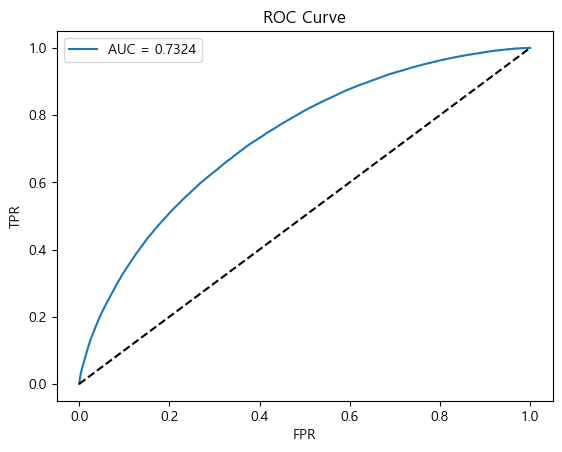

In [14]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [41]:
# 학습 후 feature importance 확인
best_pipe = grid.best_estimator_

feature_names = best_pipe[:-1].get_feature_names_out()
importances = best_pipe['model'].feature_importances_

importance_df = pd.DataFrame({
    '컬럼': feature_names,
    '중요도': importances
}).sort_values('중요도', ascending=False).reset_index(drop=True)

print(importance_df.head(50))

                                       컬럼       중요도
0                           num__int_rate  0.660669
1                            cat__grade_A  0.093166
2                    cat__term_ 60 months  0.057627
3                         num__issue_year  0.052011
4                        num__avg_cur_bal  0.047292
5               num__acc_open_past_24mths  0.011031
6                          num__loan_amnt  0.009600
7                                num__dti  0.009525
8                 cat__emp_length_unknown  0.008876
9                           num__fico_mid  0.008070
10                        num__annual_inc  0.006589
11                   num__num_actv_rev_tl  0.005918
12                   cat__term_ 36 months  0.005917
13                           cat__grade_D  0.004082
14                           cat__grade_C  0.003428
15                          num__mort_acc  0.002988
16                num__mths_since_rcnt_il  0.002354
17               cat__home_ownership_RENT  0.001997
18          

In [42]:
# 중요도 0 초과 컬럼만 추출 (원래 컬럼명으로 변환)
selected_features = importance_df[importance_df['중요도'] > 0]['컬럼'].tolist()

# num__, cat__ 접두사 제거해서 원본 컬럼명 복원
selected_original = set()
for f in selected_features:
    col = f.split('__')[1]          # num__int_rate → int_rate
    col = col.split('_')[0] if 'cat__' not in f else col  
    selected_original.add(col.strip())

# 확인
print(selected_original)

{'num', 'mort', 'acc', 'int', 'fico', 'issue', 'emp_length_unknown', 'loan', 'grade_A', 'revol', 'term_ 60 months', 'grade_C', 'term_ 36 months', 'avg', 'total', 'dti', 'home_ownership_MORTGAGE', 'annual', 'verification_status_Not Verified', 'grade_B', 'home_ownership_RENT', 'bc', 'grade_D', 'mths', 'tot'}
